In [1]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything-2.git'

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 12.8 MB/s eta 0:00:00


In [2]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_large.pt

In [3]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

checkpoint = "./sam2_hiera_large.pt"
model_cfg = "sam2_hiera_l.yaml"
sam2_model = build_sam2(model_cfg, checkpoint, device="cuda")
predictor = SAM2ImagePredictor(sam2_model)

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('File has been uploaded "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving test.png to test.png
Đã tải lên file "test.png" với độ dài 455643 bytes


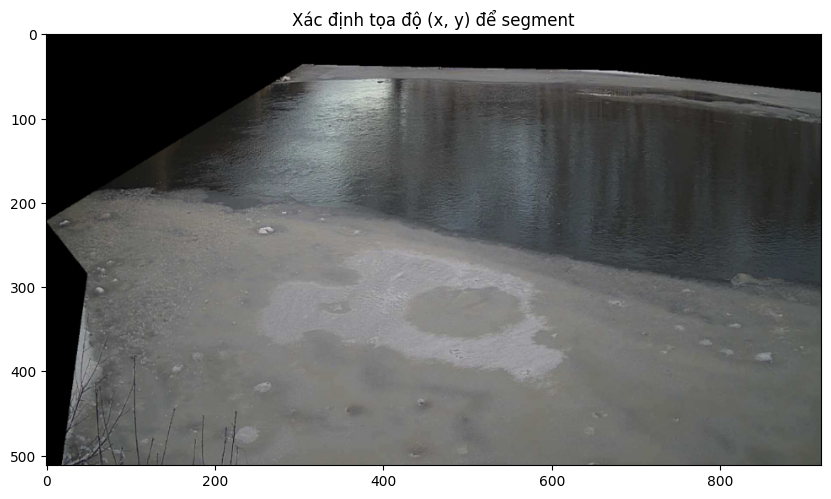

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

image_path = "test.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image)

plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis('on')
plt.title("Determine the (x, y) coordinates for segmentation")
plt.show()

In [8]:
input_points = np.array([[600, 200]])
input_labels = np.array([1])

masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True,
)

best_mask_idx = np.argmax(scores)
best_mask = masks[best_mask_idx]

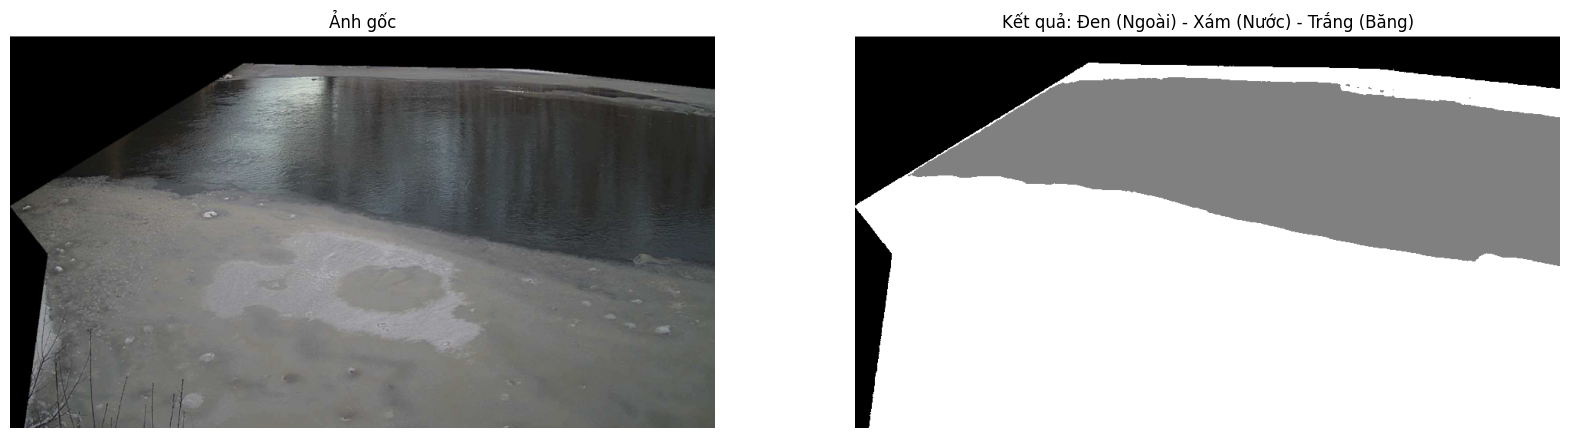

Đã sửa xong và lưu file final_mask.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

mask_bool = best_mask.astype(bool)
if len(mask_bool.shape) == 3:
    mask_bool = mask_bool.squeeze(0)

color_mask = np.full(image.shape, 255, dtype=np.uint8)

outside_mask = np.all(image <= 5, axis=-1)
color_mask[outside_mask] = 0

color_mask[mask_bool] = [128, 128, 128]

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(image)
ax[0].set_title("Original photo")
ax[0].axis('off')

ax[1].imshow(color_mask)
ax[1].set_title("Results: Black (Outside) - Gray (Water) - White (Ice)")
ax[1].axis('off')

plt.show()

cv2.imwrite("final_mask.png", cv2.cvtColor(color_mask, cv2.COLOR_RGB2BGR))
print("Finished editing and saved the final_mask file.png")